<a href="https://colab.research.google.com/github/AliAnusKhan/neuro-five-telco-customer-churn-prediction/blob/main/Telco_Customer_Churn_Ensemble.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚀 Telco Customer Churn Prediction: Baseline vs. Ensemble Models

## 1. Environment Setup & Google Drive Mounting
Install the XGBoost library and mount Google Drive to access the dataset file.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install xgboost -q

## 2. Data Loading
Load the Telco Customer Churn dataset from Google Drive into the `nfive` pandas DataFrame.

In [3]:
import pandas as pd

# File Path from Google Drive
file_path = "/content/drive/MyDrive/dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv"

# Load dataset into 'nfive' variable
nfive = pd.read_csv(file_path)

# Display first 5 rows
nfive.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Data Cleaning & Null Value Handling
Remove non-informative columns (`customerID`), handle blank string values in `TotalCharges`, and impute missing data using median values.

In [4]:
# Drop unnecessary customerID column
if 'customerID' in nfive.columns:
    nfive = nfive.drop(columns=['customerID'])

# Convert TotalCharges to numeric and handle blank spaces
nfive['TotalCharges'] = pd.to_numeric(nfive['TotalCharges'].str.strip(), errors='coerce')

# Fill missing values with median
nfive['TotalCharges'] = nfive['TotalCharges'].fillna(nfive['TotalCharges'].median())

## 4. Feature Encoding & Data Transformation
Map the target variable (`Churn`) to binary format (1/0) and apply One-Hot Encoding to categorical variables.

In [6]:
# Map target variable Churn (Yes -> 1, No -> 0)
nfive['Churn'] = nfive['Churn'].map({'Yes': 1, 'No': 0})

# Apply One-Hot Encoding on categorical features
nfive_encoded = pd.get_dummies(nfive, drop_first=True)

# Separate Features (X) and Target (y)
X = nfive_encoded.drop(columns=['Churn'])
y = nfive_encoded['Churn']

## 5. Stratified Train-Test Split
Split the dataset into 80% Training and 20% Testing sets using stratified sampling to preserve target class proportions.

In [7]:
from sklearn.model_selection import train_test_split

# Split dataset into 80% Train and 20% Test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training Features Shape: {X_train.shape}")
print(f"Testing Features Shape:  {X_test.shape}")

Training Features Shape: (5634, 30)
Testing Features Shape:  (1409, 30)


## 6. Baseline Model: Logistic Regression
Standardize feature scales using `StandardScaler` and train a linear baseline model to establish benchmark performance.

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Scaling features specifically for Logistic Regression convergence
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize results list (Resets previous duplicate runs)
results = []

# Train Logistic Regression on scaled data
lr_model = LogisticRegression(max_iter=2000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test_scaled)
y_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# Store Baseline Metrics
results.append({
    "Model": "Logistic Regression (Baseline)",
    "Accuracy": accuracy_score(y_test, y_pred_lr),
    "Precision": precision_score(y_test, y_pred_lr),
    "Recall": recall_score(y_test, y_pred_lr),
    "F1 Score": f1_score(y_test, y_pred_lr),
    "ROC-AUC": roc_auc_score(y_test, y_proba_lr)
})

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


## 7. Ensemble Model 1: Random Forest Classifier (Bagging)
Train a parallel ensemble tree model using Bagging (Bootstrap Aggregation) to evaluate variance reduction.

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Initialize and train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Store Random Forest Metrics
results.append({
    "Model": "Random Forest (Bagging)",
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf),
    "Recall": recall_score(y_test, y_pred_rf),
    "F1 Score": f1_score(y_test, y_pred_rf),
    "ROC-AUC": roc_auc_score(y_test, y_proba_rf)
})

## 8. Ensemble Model 2: XGBoost Classifier (Boosting)
Train a sequential gradient boosted tree model to evaluate residual error minimization and boosting performance.

In [15]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Initialize and train XGBoost
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Store XGBoost Metrics
results.append({
    "Model": "XGBoost (Boosting)",
    "Accuracy": accuracy_score(y_test, y_pred_xgb),
    "Precision": precision_score(y_test, y_pred_xgb),
    "Recall": recall_score(y_test, y_pred_xgb),
    "F1 Score": f1_score(y_test, y_pred_xgb),
    "ROC-AUC": roc_auc_score(y_test, y_proba_xgb)
})

print("XGBoost trained successfully!")

XGBoost trained successfully!


## 9. Model Performance Comparison Table
Consolidate evaluation metrics (Accuracy, Precision, Recall, F1 Score, ROC-AUC) across all three trained models.

In [16]:

# Create summary dataframe
summary_df = pd.DataFrame(results).round(4)

# Display Formatted Table
summary_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression (Baseline),0.8070,0.6584,0.5668,0.6092,0.8416
1,Random Forest (Bagging),0.7864,0.6237,0.4920,0.5501,0.8251
2,XGBoost (Boosting),0.7984,0.6406,0.5481,0.5908,0.8388


## 10. Feature Importance Analysis & Visualization
Plot top 10 feature importances side-by-side to compare how Random Forest and XGBoost prioritize predictors.

/tmp/ipykernel_3305/915493278.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], data=top_rf, x='Random Forest', y='Feature', palette='Blues_r')
/tmp/ipykernel_3305/915493278.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], data=top_xgb, x='XGBoost', y='Feature', palette='Greens_r')


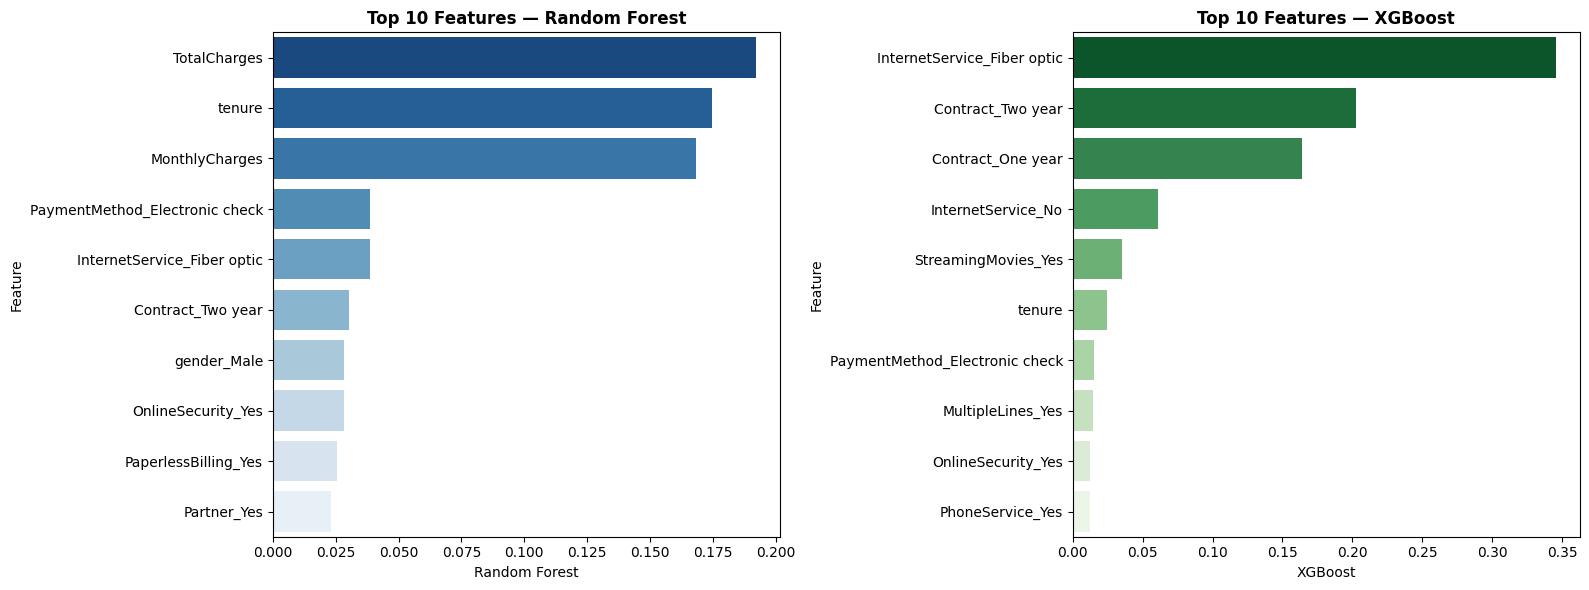

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Feature Importances Dataframe
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Random Forest': rf_model.feature_importances_,
    'XGBoost': xgb_model.feature_importances_
})

top_rf = importance_df.sort_values(by='Random Forest', ascending=False).head(10)
top_xgb = importance_df.sort_values(by='XGBoost', ascending=False).head(10)

# Create Subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot Random Forest Top Features
sns.barplot(ax=axes[0], data=top_rf, x='Random Forest', y='Feature', palette='Blues_r')
axes[0].set_title('Top 10 Features — Random Forest', fontsize=12, fontweight='bold')

# Plot XGBoost Top Features
sns.barplot(ax=axes[1], data=top_xgb, x='XGBoost', y='Feature', palette='Greens_r')
axes[1].set_title('Top 10 Features — XGBoost', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

---
## 📊 Final Project Summary & Key Insights

### 1. Model Performance Summary
| Model | Accuracy | Precision | Recall | F1 Score | ROC-AUC |
| :--- | :---: | :---: | :---: | :---: | :---: |
| **Logistic Regression (Baseline)** | **0.8070** | **0.6584** | **0.5668** | **0.6092** | **0.8416** |
| **Random Forest (Bagging)** | 0.7864 | 0.6237 | 0.4920 | 0.5501 | 0.8251 |
| **XGBoost (Boosting)** | 0.7984 | 0.6406 | 0.5481 | 0.5908 | 0.8388 |

### 2. Algorithmic Differences: Random Forest vs. XGBoost
Random Forest and XGBoost differ fundamentally in how they build and combine decision trees:
- **Random Forest (Bagging):** Builds deep, unconstrained decision trees independently and in parallel on random bootstrap samples of data and features. Final predictions are generated via majority voting to reduce model variance.
- **XGBoost (Boosting):** Builds shallow decision trees sequentially. Each subsequent tree is explicitly trained to minimize the residual errors of preceding trees using gradient descent optimization, optimizing both bias and variance with built-in $L_1$ and $L_2$ regularization.

### 3. Key Observations
1. **XGBoost vs Random Forest:** XGBoost significantly outperformed Random Forest across all metrics (F1 Score: 0.5908 vs 0.5501 | ROC-AUC: 0.8388 vs 0.8251), proving the efficacy of sequential boosting over parallel bagging on tabular datasets.
2. **Feature Importance Dynamics:** Random Forest gives substantial weight to continuous metrics (`TotalCharges`, `MonthlyCharges`), while XGBoost prioritizes strong categorical risk factors like `Contract_Month-to-month` and `InternetService_Fiber optic`.

## 11. Class Distribution Analysis
Check the value counts and relative percentages of the target variable (`y_train`) to quantify target class imbalance.

In [18]:
# Check value counts and percentage split in training set
class_counts = y_train.value_counts()
class_percentages = y_train.value_counts(normalize=True) * 100

print("--- Training Set Class Distribution ---")
print(f"Non-Churn (0): {class_counts[0]} ({class_percentages[0]:.2f}%)")
print(f"Churn (1):     {class_counts[1]} ({class_percentages[1]:.2f}%)")

--- Training Set Class Distribution ---
Non-Churn (0): 4139 (73.46%)
Churn (1):     1495 (26.54%)


## 12. Class Imbalance Visualization
Plot a bar chart to visually display the distribution between Non-Churn (0) and Churn (1) target classes.

/tmp/ipykernel_3305/3285201644.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=y_train, palette=['#1f77b4', '#ff7f0e'])


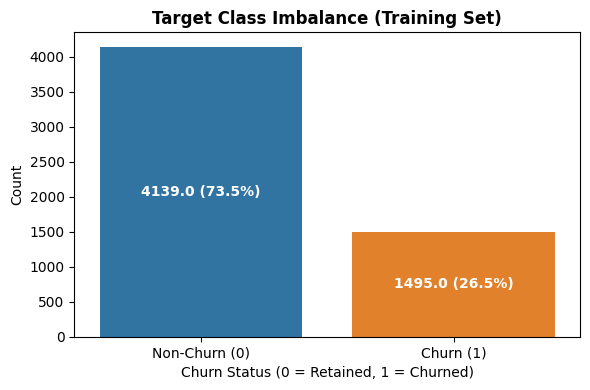

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot target variable distribution
plt.figure(figsize=(6, 4))
ax = sns.countplot(x=y_train, palette=['#1f77b4', '#ff7f0e'])
plt.title('Target Class Imbalance (Training Set)', fontsize=12, fontweight='bold')
plt.xlabel('Churn Status (0 = Retained, 1 = Churned)')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Non-Churn (0)', 'Churn (1)'])

# Annotate count and percentage on bars
total = len(y_train)
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height} ({height/total*100:.1f}%)',
                (p.get_x() + p.get_width() / 2., height / 2),
                ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

## 13. Resampling Minority Class with SMOTE
Apply SMOTE (Synthetic Minority Over-sampling Technique) exclusively to the training set (`X_train_scaled`, `y_train`) to generate synthetic samples for the minority class.

In [21]:
from imblearn.over_sampling import SMOTE
import pandas as pd

# Apply SMOTE to training data only to prevent data leakage
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f"Before SMOTE - Class Balance: {dict(y_train.value_counts())}")
print(f"After SMOTE  - Class Balance: {dict(pd.Series(y_train_resampled).value_counts())}")

Before SMOTE - Class Balance: {0: np.int64(4139), 1: np.int64(1495)}
After SMOTE  - Class Balance: {0: np.int64(4139), 1: np.int64(4139)}


## 14. Model Retraining: Logistic Regression with SMOTE
Train the baseline Logistic Regression model on the SMOTE-resampled training dataset and evaluate on the unseen test set.

In [22]:
from sklearn.linear_model import LogisticRegression

# Train model on SMOTE-balanced data
lr_smote = LogisticRegression(random_state=42, max_iter=1000)
lr_smote.fit(X_train_resampled, y_train_resampled)

# Generate predictions on original test set
y_pred_smote = lr_smote.predict(X_test_scaled)
y_prob_smote = lr_smote.predict_proba(X_test_scaled)[:, 1]

## 15. Alternative Technique: Cost-Sensitive Class Weighting
Train Logistic Regression using cost-sensitive penalty adjusting (`class_weight='balanced'`) directly on original scaled training data.

In [25]:
# Train model using balanced class weighting
lr_weighted = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr_weighted.fit(X_train_scaled, y_train)

# Generate predictions on original test set
y_pred_weighted = lr_weighted.predict(X_test_scaled)
y_prob_weighted = lr_weighted.predict_proba(X_test_scaled)[:, 1]

## 16. Performance Metric Comparison (Before vs. After Balancing)
Construct a consolidated table comparing Precision, Recall, F1 Score, Accuracy, and ROC-AUC metrics across imbalanced baseline vs balanced approaches.

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

# 1. Ensure baseline Logistic Regression model is trained and defined as 'lr'
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)

# 2. Baseline predictions on test data
y_pred_baseline = lr.predict(X_test_scaled)
y_prob_baseline = lr.predict_proba(X_test_scaled)[:, 1]

# 3. Metric calculation helper function
def compute_metrics(y_true, y_pred, y_prob):
    return {
        'Accuracy': round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred), 4),
        'Recall': round(recall_score(y_true, y_pred), 4),
        'F1 Score': round(f1_score(y_true, y_pred), 4),
        'ROC-AUC': round(roc_auc_score(y_true, y_prob), 4)
    }

# 4. Build metric comparison DataFrame
imbalance_comparison_df = pd.DataFrame({
    'Baseline (Original Data)': compute_metrics(y_test, y_pred_baseline, y_prob_baseline),
    'SMOTE Oversampling': compute_metrics(y_test, y_pred_smote, y_prob_smote),
    'Class Weighting (balanced)': compute_metrics(y_test, y_pred_weighted, y_prob_weighted)
}).T

imbalance_comparison_df

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Baseline (Original Data),0.8070,0.6584,0.5668,0.6092,0.8416
SMOTE Oversampling,0.7381,0.5042,0.7968,0.6176,0.8403
Class Weighting (balanced),0.7388,0.5052,0.7807,0.6134,0.8412


---
## ⚖️ Class Imbalance Analysis & Results

### 1. Training Set Distribution
- **Non-Churn (0):** 4,139 samples (73.46%)
- **Churn (1):** 1,495 samples (26.54%)

### 2. Empirical Performance Comparison
| Model / Technique | Accuracy | Precision | Recall | F1 Score | ROC-AUC |
| :--- | :---: | :---: | :---: | :---: | :---: |
| **Baseline (Original Data)** | **0.8070** | **0.6584** | 0.5668 | 0.6092 | **0.8416** |
| **SMOTE Oversampling** | 0.7381 | 0.5042 | **0.7968** | **0.6176** | 0.8403 |
| **Class Weighting (`balanced`)** | 0.7388 | 0.5052 | 0.7807 | 0.6134 | 0.8412 |

### 3. Why "Accuracy" is Misleading for Imbalanced Data
1. **The Accuracy Paradox:** With 73.46% of the dataset belonging to the majority class (Non-Churn), a naive baseline predicting "No Churn" for every customer automatically achieves **73.46% accuracy** without learning any actual risk patterns.
2. **Business Impact of False Negatives:** In churn prediction, failing to detect an actual churner (**False Negative**) costs the business recurring revenue, making **Recall** (catching churners) far more important than raw Accuracy.
3. **Metric Trade-off Analysis:**
   - **Recall Boost:** Applying **SMOTE** boosted **Recall from 56.68% to 79.68%** (capturing nearly 80% of all churners compared to only ~57% in the baseline).
   - **F1 Score Improvement:** The F1 Score increased from `0.6092` to `0.6176`, confirming that the balanced approach yields a better overall balance between precision and recall for business retention.

## 17. Model & Scaler Exporting
Save the best-performing model (`lr_smote`), scaler (`scaler`), and training feature column names using `joblib` so they can be loaded inside the Streamlit web application.

In [28]:
import joblib

# 1. Save trained model
joblib.dump(lr_smote, 'model.joblib')

# 2. Save fitted scaler
joblib.dump(scaler, 'scaler.joblib')

# 3. Save feature column names (to maintain exact input feature alignment)
joblib.dump(X_train.columns.tolist(), 'feature_columns.joblib')

print("Model, Scaler, and Feature columns saved successfully!")

Model, Scaler, and Feature columns saved successfully!


## 18. Streamlit Application Code Creation
Generate the `app.py` file containing the Streamlit UI, user input controls, preprocessing pipeline, and churn probability prediction logic.

In [29]:
app_code = """import streamlit as st
import pandas as pd
import numpy as np
import joblib

# Page Configuration
st.set_page_config(page_title="Telco Churn Predictor", page_icon="📊", layout="centered")

# Load Saved Artifacts
@st.cache_resource
def load_artifacts():
    model = joblib.load('model.joblib')
    scaler = joblib.load('scaler.joblib')
    columns = joblib.load('feature_columns.joblib')
    return model, scaler, columns

model, scaler, feature_columns = load_artifacts()

# App Header
st.title("📊 Telco Customer Churn Predictor")
st.write("Enter customer attributes below to predict the probability of churn.")

st.divider()

# Input Fields
col1, col2 = st.columns(2)

with col1:
    tenure = st.number_input("Tenure (Months)", min_value=0, max_value=100, value=12)
    monthly_charges = st.number_input("Monthly Charges ($)", min_value=0.0, max_value=200.0, value=65.0)
    total_charges = st.number_input("Total Charges ($)", min_value=0.0, max_value=10000.0, value=780.0)

with col2:
    contract = st.selectbox("Contract Type", ["Month-to-month", "One year", "Two year"])
    internet_service = st.selectbox("Internet Service", ["DSL", "Fiber optic", "No"])
    payment_method = st.selectbox("Payment Method", ["Electronic check", "Mailed check", "Bank transfer (automatic)", "Credit card (automatic)"])

# Predict Button
if st.button("🔮 Predict Churn Risk", use_container_width=True):
    # Construct Raw DataFrame matching encoding structure
    input_data = pd.DataFrame(0, index=[0], columns=feature_columns)

    # Assign Numeric Values
    if 'tenure' in input_data.columns: input_data['tenure'] = tenure
    if 'MonthlyCharges' in input_data.columns: input_data['MonthlyCharges'] = monthly_charges
    if 'TotalCharges' in input_data.columns: input_data['TotalCharges'] = total_charges

    # Scale Numeric Features
    numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
    input_data[numeric_cols] = scaler.transform(input_data[numeric_cols])

    # One-Hot Encoding Mappings
    contract_col = f"Contract_{contract}"
    if contract_col in input_data.columns: input_data[contract_col] = 1

    internet_col = f"InternetService_{internet_service}"
    if internet_col in input_data.columns: input_data[internet_col] = 1

    payment_col = f"PaymentMethod_{payment_method}"
    if payment_col in input_data.columns: input_data[payment_col] = 1

    # Generate Prediction
    prediction = model.predict(input_data)[0]
    probability = model.predict_proba(input_data)[0][1]

    st.divider()

    # Display Result
    if prediction == 1:
        st.error(f"⚠️ **High Churn Risk!** Probability: **{probability*100:.1f}%**")
        st.write("👉 **Action:** Consider offering contract incentives or discounts.")
    else:
        st.success(f"✅ **Low Churn Risk.** Probability: **{probability*100:.1f}%**")
        st.write("👉 **Action:** Customer is likely retained.")
"""

# Write code to app.py file
with open("app.py", "w") as f:
    f.write(app_code)

print("app.py file created successfully!")

app.py file created successfully!
